<a href="https://colab.research.google.com/github/hrishikeshrprasad367/ML/blob/main/1BM23CS367_Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
income=pd.read_csv("income.csv")
print(income.head())
print(income.info())
print(income.describe)

   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   income_level  
0             0  
1             0  
2             0  
3             0  
4             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   fnlwgt          48842 non-null  int64
 2   education_num   48842 non-null  int64
 3   capital_gain    48842 non-null  int64
 4   capital_loss    48842 non-null  int64
 5   hours_per_week 

   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   income_level  
0             0  
1             0  
2             0  
3             0  
4             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   fnlwgt          48842 non-null  int64
 2   education_num   48842 non-null  int64
 3   capital_gain    48842 non-null  int64
 4   capital_loss    48842 non-null  int64
 5   hours_per_week 

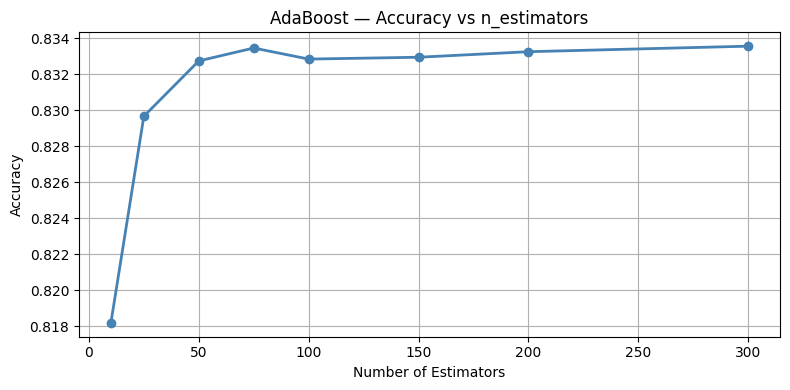

In [3]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Load dataset
income = pd.read_csv("income.csv")
print(income.head())
print(income.info())

# Features and target
X = income.drop("income_level", axis=1)
y = income["income_level"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Part i: n_estimators = 10 ──────────────────────────────────────────────────
ada_10 = AdaBoostClassifier(n_estimators=10, random_state=42)
ada_10.fit(X_train, y_train)
y_pred_10 = ada_10.predict(X_test)

print("\n── n_estimators = 10 ──")
print(f"Accuracy: {accuracy_score(y_test, y_pred_10):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_10))

# ── Part ii: Fine-tuning — sweep over different n_estimators ──────────────────
estimator_range = [10, 25, 50, 75, 100, 150, 200, 300]
scores = []

for n in estimator_range:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    ada.fit(X_train, y_train)
    score = accuracy_score(y_test, ada.predict(X_test))
    scores.append(score)
    print(f"n_estimators={n:>4}  →  Accuracy: {score:.4f}")

# Best result
best_idx = scores.index(max(scores))
best_n   = estimator_range[best_idx]
best_acc = scores[best_idx]
print(f"\n✅ Best Accuracy : {best_acc:.4f}  using n_estimators = {best_n}")

# Confusion matrix for best model
best_model = AdaBoostClassifier(n_estimators=best_n, random_state=42)
best_model.fit(X_train, y_train)
print("Confusion Matrix (best model):\n", confusion_matrix(y_test, best_model.predict(X_test)))

# ── Plot accuracy vs n_estimators ─────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(estimator_range, scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost — Accuracy vs n_estimators")
plt.grid(True)
plt.tight_layout()
plt.show()